# Пайплайн аугментации

Ноутбук последовательно:
1. Разбивает данные на **train/test** (80/20, стратифицированно)
2. Аугментирует **только train** через 3 этапа
3. Оценивает baseline-классификаторы **на test**

**Этапы аугментации:**
1. LLM-генерация (< 15 → 15)
2. Парафраз через LLM (< 35 → 35)
3. Обратный перевод (< 50 → 50)

**Классификация (baseline):**
- Linear SVM (TF-IDF)
- Logistic Regression (TF-IDF)
- Multinomial Naive Bayes (TF-IDF)
- rubert-tiny2 (fine-tuning)

___
## Подготовка окружения (Запуск в Colab)

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

REPO_URL = 'https://github.com/KVTur23/Mifi_VKR.git'
REPO_BRANCH = 'fine-tune'
REPO_DIR = Path('/content/VKR')
PROJECT_ROOT = REPO_DIR / 'code'

DRIVE_ROOT = Path('/content/drive/MyDrive/VKR')
DRIVE_DATA = DRIVE_ROOT / 'Data'
DRIVE_RESULTS = DRIVE_ROOT / 'results'
DRIVE_LOGS = DRIVE_ROOT / 'logs'


In [ ]:
import shutil
import subprocess

if (REPO_DIR / '.git').exists():
    print('Репо уже клонирован — обновляю из origin')
    subprocess.run(['git', '-C', str(REPO_DIR), 'fetch', 'origin'], check=True)
    subprocess.run(['git', '-C', str(REPO_DIR), 'checkout', '-B', REPO_BRANCH, f'origin/{REPO_BRANCH}'], check=True)
else:
    print(f'Клонирую {REPO_URL} в {REPO_DIR}')
    subprocess.run(['git', 'clone', '-b', REPO_BRANCH, REPO_URL, str(REPO_DIR)], check=True)

def link_to_drive(name, drive_path):
    local_path = PROJECT_ROOT / name
    drive_path.parent.mkdir(parents=True, exist_ok=True)

    drive_missing_or_empty = not drive_path.exists() or not any(drive_path.iterdir())
    if drive_missing_or_empty:
        if local_path.exists() and not local_path.is_symlink():
            if drive_path.exists():
                shutil.rmtree(drive_path)
            shutil.copytree(local_path, drive_path)
        else:
            drive_path.mkdir(parents=True, exist_ok=True)

    if local_path.is_symlink() or local_path.is_file():
        local_path.unlink()
    elif local_path.exists():
        shutil.rmtree(local_path)

    local_path.symlink_to(drive_path, target_is_directory=True)
    print(f'{name}: {local_path} -> {drive_path}')

link_to_drive('Data', DRIVE_DATA)
link_to_drive('results', DRIVE_RESULTS)
link_to_drive('logs', DRIVE_LOGS)

commit = subprocess.run(
    ['git', '-C', str(REPO_DIR), 'log', '-1', '--oneline'],
    capture_output=True, text=True, check=True,
).stdout.strip()
print(f'\nТекущий коммит: {commit}')


In [ ]:
import sys
import pandas as pd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%cd {PROJECT_ROOT}

from src.utils.data_loader import (
    load_dataset, get_class_distribution, split_train_test, load_test_set,
    LABEL_COL, RANDOM_SEED, DATA_DIR, ORIGINAL_FILE,
)

print(f'Корень проекта: {PROJECT_ROOT}')
print(f'Папка данных:   {DATA_DIR}')
print(f'Drive Data:     {DRIVE_DATA}')

from src.utils.pipeline_config import load_pipeline_config

# === GPU ПРОФИЛЬ — МЕНЯЙ ЗДЕСЬ ===
GPU = 'A100_40'  # варианты: 'T4', 'L4', 'A100_40', 'A100_80', 'H100'
pipeline_cfg = load_pipeline_config(GPU)


/content/drive/MyDrive/VKR/code
Корень проекта: /content/drive/MyDrive/VKR/code
Папка данных:   /content/drive/MyDrive/VKR/code/Data
[Config] GPU: A100_40 (40GB), NLLB: facebook/nllb-200-3.3B, batch: 64


## Подготовка окружения (Локальный запуск)

In [ ]:
# import sys
# from pathlib import Path
# import pandas as pd

# PROJECT_ROOT = Path("/Users/kvt/Documents/VKR/code")         

# # Добавляем корень в sys.path
# if str(PROJECT_ROOT) not in sys.path:
#     sys.path.insert(0, str(PROJECT_ROOT))

# %cd {PROJECT_ROOT}

# from src.utils.data_loader import (
#     load_dataset, get_class_distribution, split_train_test, load_test_set,
#     LABEL_COL, RANDOM_SEED, DATA_DIR, ORIGINAL_FILE,
# )

# print(f"Корень проекта: {PROJECT_ROOT}")
# print(f"Папка данных:   {DATA_DIR}")

# from src.utils.pipeline_config import load_pipeline_config

# # === GPU ПРОФИЛЬ — МЕНЯЙ ЗДЕСЬ ===
# GPU = "A100_40"  # варианты: "T4", "L4", "A100_40", "A100_80", "H100"
# pipeline_cfg = load_pipeline_config(GPU)

/Users/kvt/Documents/VKR/code
Корень проекта: /Users/kvt/Documents/VKR/code
Папка данных:   /Users/kvt/Documents/VKR/code/Data
[Config] GPU: A100_40 (40GB), NLLB: facebook/nllb-200-3.3B, batch: 64


/Users/kvt/miniconda3/envs/vkr_clean/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
# Ставим зависимости из requirements.txt
!pip install -q -r {PROJECT_ROOT}/requirements.txt

___
## Предобработка данных

Очистка сырых данных: удаление дубликатов, повторов слов, циклов, обрезка приложений.

`data.json` → `data_after_eda.csv`

In [4]:
from src.utils.data_cleaner import run as run_cleaning

eda_path = DATA_DIR / "data_after_eda.csv"

if eda_path.exists():
    print(f"data_after_eda.csv уже существует ({len(pd.read_csv(eda_path))} записей), пропускаем")
else:
    run_cleaning()

data_after_eda.csv уже существует (1750 записей), пропускаем


___
## Разделение на train / test

Стратифицированное разбиение 80/20 с гарантией минимум 1 примера на класс в каждой части.
Аугментация применяется **только к train**. Оценка — **на test**.

In [5]:
from src.utils.data_loader import STAGE_FILES, TEST_FILE

train_path = DATA_DIR / STAGE_FILES[0]  # train_after_eda.csv
test_path = DATA_DIR / TEST_FILE         # data_test.csv

if train_path.exists() and test_path.exists():
    # Уже разбито — просто загружаем
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)
    print(f"Train/test уже существуют, загружены из файлов")
else:
    # Первый запуск — разбиваем оригинал
    original_path = DATA_DIR / ORIGINAL_FILE
    df_original = pd.read_csv(original_path)
    print(f"Загружен оригинал: {original_path.name} ({len(df_original)} записей)")
    df_train, df_test = split_train_test(df_original)

print(f"\nTrain: {len(df_train)} ({len(df_train)/(len(df_train)+len(df_test))*100:.0f}%)")
print(f"Test:  {len(df_test)} ({len(df_test)/(len(df_train)+len(df_test))*100:.0f}%)")

Train/test уже существуют, загружены из файлов

Train: 1409 (81%)
Test:  341 (19%)


In [6]:
# Распределение по классам в train и test
dist_train = get_class_distribution(df_train)
dist_test = get_class_distribution(df_test)

print(f"{'Класс':<70} {'Train':>6} {'Test':>5}")
print("-" * 85)
for cls in dist_train.index:
    tr = dist_train[cls]
    te = dist_test.get(cls, 0)
    print(f"  {cls:<68} {tr:>6} {te:>5}")
print("-" * 85)
print(f"  {'ИТОГО':<68} {len(df_train):>6} {len(df_test):>5}")

Класс                                                                   Train  Test
-------------------------------------------------------------------------------------
  Блок технического директора                                             197    49
  Блок директора по мощностям                                             193    48
  Блок директора по строительству                                         131    32
  Управление по проектным работам                                         108    27
  Блок заместителя генерального директора по безопасности                  99    24
  Генеральный директор                                                     82    20
  Проект "Нефтяные краюшки"                                                64    15
  Блок деректора по газу                                                   57    14
  Блок заместителя генерального директора по закупкам                      54    13
  Блок заместителя генерального директора по организационным вопросам     

___
## Baseline — классификация ДО аугментации

Обучаем те же модели на **оригинальном train** (без аугментации), 
чтобы потом сравнить с результатами после аугментации.

In [11]:
from src.classification.evaluate import load_data, evaluate_model
from src.classification.embeddings import prepare_features
from sklearn.preprocessing import LabelEncoder

# Загружаем оригинальный train (stage=0) и test
df_train_orig = load_dataset(stage=0)
df_test_baseline = load_test_set()

X_train_orig, y_train_orig_raw, X_test_orig, y_test_orig_raw = prepare_features(
    df_train_orig, df_test_baseline, use_cache=False
)

le_baseline = LabelEncoder()
y_train_orig = le_baseline.fit_transform(y_train_orig_raw)
y_test_orig = le_baseline.transform(y_test_orig_raw)
label_names_baseline = le_baseline.classes_

print(f"Train (без аугментации): {X_train_orig.shape}")
print(f"Test: {X_test_orig.shape}")
print(f"Классов: {len(label_names_baseline)}")

[Данные] Найден чекпоинт этапа 0: train_after_eda.csv (1409 записей)
[Данные] Тестовая выборка: data_test.csv (341 записей)
[TF-IDF] Параметры: max_features=50000, ngram_range=(1, 2)
[TF-IDF] Обучаю на 1409 текстах...
[TF-IDF] Готово: train (1409, 27985), test (341, 27985)
Train (без аугментации): (1409, 27985)
Test: (341, 27985)
Классов: 36


In [12]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

baseline_results = []

print("=" * 60)
print("BASELINE (без аугментации)")
print("=" * 60)

baseline_results.append(evaluate_model(
    name="[Baseline] Linear SVM",
    estimator=LinearSVC(max_iter=10000, random_state=RANDOM_SEED, dual="auto"),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

baseline_results.append(evaluate_model(
    name="[Baseline] Logistic Regression",
    estimator=LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

baseline_results.append(evaluate_model(
    name="[Baseline] Multinomial Naive Bayes",
    estimator=MultinomialNB(),
    X_train=X_train_orig, y_train=y_train_orig,
    X_test=X_test_orig, y_test=y_test_orig,
    label_names=label_names_baseline,
    param_grid={"alpha": [0.01, 0.1, 0.5, 1.0]},
))

BASELINE (без аугментации)
КЛАССИФИКАЦИЯ: [Baseline] Linear SVM
[[Baseline] Linear SVM] Train: 1409, Test: 341, Классов: 36


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[[Baseline] Linear SVM] Лучшие параметры: {'C': 1} (CV macro F1 = 0.4682)

[[Baseline] Linear SVM] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4208
  Macro F1:          0.4434

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.00      0.00      0.00         1
                                                      Блок деректора по газу       0.78      0.50      0.61        14
                                          Блок директора по газовым проектам       0.50      0.17      0.25         6
                                                 Блок директора по мощностям       0.69      0.94      0.80        48
                                                 Блок директора по персоналу       1.00      0.67      0.80         3
                                                  Блок директора по портфелю       0.00      0.00      

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[[Baseline] Logistic Regression] Лучшие параметры: {'C': 10} (CV macro F1 = 0.3717)

[[Baseline] Logistic Regression] Результаты на тестовой выборке:
  Balanced Accuracy: 0.3089
  Macro F1:          0.3350

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.00      0.00      0.00         1
                                                      Блок деректора по газу       0.75      0.21      0.33        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.65      0.94      0.77        48
                                                 Блок директора по персоналу       0.00      0.00      0.00         3
                                                  Блок директора по портфелю       0

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


[[Baseline] Multinomial Naive Bayes] Лучшие параметры: {'alpha': 0.01} (CV macro F1 = 0.4461)

[[Baseline] Multinomial Naive Bayes] Результаты на тестовой выборке:
  Balanced Accuracy: 0.3849
  Macro F1:          0.4026

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.00      0.00      0.00         1
                                                      Блок деректора по газу       0.75      0.43      0.55        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.70      0.96      0.81        48
                                                 Блок директора по персоналу       1.00      0.67      0.80         3
                                                  Блок директора по по

In [13]:
from src.classification.rubert_classifier import train_and_evaluate

# --- Настройки моделей ---
RUBERT_CONFIGS = [
    {
        "model_name": "cointegrated/rubert-tiny2",
        "short_name": "rubert-tiny2",
        "lr": 5e-4,
        "num_epochs": 15,
        "batch_size": 32,
    },
    {
        "model_name": "DeepPavlov/rubert-base-cased",
        "short_name": "rubert-base",
        "lr": 5e-5,
        "num_epochs": 15,
        "batch_size": 32,
    },
]

for cfg in RUBERT_CONFIGS:
    baseline_results.append(train_and_evaluate(
        df_train=df_train_orig,
        df_test=df_test_baseline,
        model_name=cfg["model_name"],
        lr=cfg["lr"],
        num_epochs=cfg["num_epochs"],
        batch_size=cfg["batch_size"],
        name=f"[Baseline] {cfg['short_name']}",
    ))


[[Baseline] rubert-tiny2] Device: cuda, Model: cointegrated/rubert-tiny2


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

  Epoch 11/15 — loss: 0.2395


  Epoch 12/15 — loss: 0.1957


  Epoch 13/15 — loss: 0.1621


  Epoch 14/15 — loss: 0.1399


  Epoch 15/15 — loss: 0.1257

[[Baseline] rubert-base] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4244
  Macro F1:          0.3972

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.50      0.57      0.53        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.79      0.85      0.82        48
                                                 Блок директора по персоналу       0.75      1.00      0.86         3
                                                  Блок директора по портфелю       0.00      0.00      0.00         4
                             

___
## Этап 1: LLM-генерация (< 15 -> 15)

Классы с менее чем 15 примерами дополняются новыми текстами,
сгенерированными через LLM.

In [8]:
# Путь до конфига модели 
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_qwen.json")
# урезанная
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_qwen_3b.json")
# квантизированная
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_qwen_14b_unsloth.json")
# print(f"Конфиг модели: {CONFIG_PATH}")
# AWQ квантизиция
# CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_vllm.json")
# print(f"Конфиг модели: {CONFIG_PATH}")

# # Если есть мощность A100 и лучше
CONFIG_PATH = str(PROJECT_ROOT / "config_models" / "aug_configs" / "model_vllm_32b.json")
print(f"Конфиг модели: {CONFIG_PATH}")

Конфиг модели: /content/drive/MyDrive/VKR/code/config_models/aug_configs/model_vllm_32b.json


In [8]:
from src.augmentation.stage1_llm_generate import run as run_stage1

run_stage1(CONFIG_PATH, pipeline_cfg=pipeline_cfg)

ЭТАП 1: LLM-генерация (< 15 → 15)
[Данные] Найден чекпоинт этапа 1: data_after_stage1.csv (1411 записей)

[Этап 1] Классов для аугментации: 11
  «Имущественные вопросы»: 1 → нужно ещё 14
  «Блок заместителя генерального директора по строительству»: 1 → нужно ещё 14
  «Подразделение по информационным технологиям»: 1 → нужно ещё 14
  «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: 1 → нужно ещё 14
  «Проект «Обустройство объектов Новейшей нейти»»: 2 → нужно ещё 13
  «Блок исполнительного директора по реализации проекта "Большое месторождение"»: 3 → нужно ещё 12
  «Проект "Обустройство площадных объектов НГКМ Поменбше"»: 5 → нужно ещё 10
  «Проект «Обустройство Интересного лицензионного участка»»: 6 → нужно ещё 9
  «Управление коммуникаций»: 6 → нужно ещё 9
  «Блок бизнес-директора»: 7 → нужно ещё 8
  «Проект "Южный"»: 10 → нужно ещё 5
[LLM] Загружаю модель через vLLM: Qwen/Qwen2.5-32B-Instruct-AWQ
INFO 03-23 12:44:49 [utils.py:233] non-default args: {'trust_remote_code': True, 'max_

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

INFO 03-23 12:45:22 [model.py:533] Resolved architecture: Qwen2ForCausalLM
INFO 03-23 12:45:22 [model.py:1582] Using max model len 8192
INFO 03-23 12:45:22 [awq_marlin.py:166] Detected that the model can run with awq_marlin, however you specified quantization=awq explicitly, so forcing awq. Use quantization=awq_marlin for faster inference
INFO 03-23 12:45:22 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=8192.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

Processed prompts:   0%|          | 0/71 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

[Валидация] Класс «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: проверяем 71 сгенерированных текстов
  [Промпт-утечка] Класс «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: отсеяно 1 текстов (LLM описала задание вместо письма)
[Валидация] Класс «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: прошло 70/71, отсеяно 1
  [Судья] Оцениваю 70 текстов для «Проект «Трубопроводный транспорт Ещё одного НГКМ»»...


Rendering conversations:   0%|          | 0/70 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/70 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  [Судья] Средняя оценка: 7.9, отсеяно < 5.0: 0, отобрано 14, средняя отобранных: 8.0
  [Генерация] Раунд 1: получено 71, после фильтров 70, после судьи 14, принято 14, всего 14/14
[Этап 1] Класс «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: добавлено 14 текстов
[Данные] Сохранён чекпоинт этапа 1: data_after_stage1.csv (1533 записей)
[Этап 1] Промежуточное сохранение: 11 классов обработано, 1533 записей

[Этап 1] Всего добавлено 122 текстов
[Данные] Сохранён чекпоинт этапа 1: data_after_stage1.csv (1533 записей)

[Этап 1] Итоговое распределение:
  «Блок технического директора»: 197 ✓
  «Блок директора по мощностям»: 193 ✓
  «Блок директора по строительству»: 131 ✓
  «Управление по проектным работам»: 108 ✓
  «Блок заместителя генерального директора по безопасности»: 99 ✓
  «Генеральный директор»: 82 ✓
  «Проект "Нефтяные краюшки"»: 64 ✓
  «Блок деректора по газу»: 57 ✓
  «Блок заместителя генерального директора по закупкам»: 54 ✓
  «Блок заместителя генерального директора по орг

In [9]:
df_after_s1 = load_dataset(stage=1)
dist_s1 = get_class_distribution(df_after_s1)
while (dist_s1 < 15).sum() != 0:# Проверяем результат после этапа 1
    print(f"Записей после этапа 1: {len(df_after_s1)}")
    print(f"Классов с < 15 примерами: {(dist_s1 < 15).sum()}")
    print(f"{"="*100}\n\n")
    print("Повторяем 1й этап")
    print(f"\n\n{"="*100}")
    run_stage1(CONFIG_PATH, pipeline_cfg=pipeline_cfg)
    df_after_s1 = load_dataset(stage=1)
    dist_s1 = get_class_distribution(df_after_s1)
print("Этап 1: Генерация с помощью LLM полностью завершен.")

[Данные] Найден чекпоинт этапа 1: data_after_stage1.csv (1533 записей)
Этап 1: Генерация с помощью LLM полностью завершен.


## 3. Этап 2: Парафраз через LLM (< 35 -> 35)

Классы с менее чем 35 примерами пополняются через перефразирование
существующих текстов — LLM получает оригинал и переписывает его
другими словами, сохраняя смысл.

In [10]:
from src.augmentation.stage2_paraphrase import run as run_stage2

run_stage2(CONFIG_PATH, pipeline_cfg=pipeline_cfg)

ЭТАП 2: Парафраз через LLM (< 35 → 35)
[Данные] Чекпоинт этапа 2 не найден, загружен этап 1: data_after_stage1.csv (1533 записей)

[Этап 2] Классов для аугментации: 25
  «Блок бизнес-директора»: 15 → нужно ещё 20
  «Имущественные вопросы»: 15 → нужно ещё 20
  «Блок заместителя генерального директора по имуществу»: 15 → нужно ещё 20
  «Блок директора по персоналу»: 15 → нужно ещё 20
  «Блок исполнительного директора по реализации проекта "Большое месторождение"»: 15 → нужно ещё 20
  «Блок заместителя генерального директора по строительству»: 15 → нужно ещё 20
  «Подразделение по информационным технологиям»: 15 → нужно ещё 20
  «Проект "Южный"»: 15 → нужно ещё 20
  «Проект "Обустройство площадных объектов НГКМ Поменбше"»: 15 → нужно ещё 20
  «Проект "Восточный"»: 15 → нужно ещё 20
  «Проект «Обустройство Интересного лицензионного участка»»: 15 → нужно ещё 20
  «Проект «Трубопроводный транспорт Ещё одного НГКМ»»: 15 → нужно ещё 20
  «Проект «Обустройство объектов Новой нефти»»: 15 → нужно

Parse safetensors files:   0%|          | 0/5 [00:00<?, ?it/s]

WARNING 03-23 13:11:57 [vllm.py:788] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 03-23 13:11:57 [vllm.py:799] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
INFO 03-23 13:11:57 [vllm.py:964] Cudagraph is disabled under eager mode
INFO 03-23 13:12:33 [llm.py:391] Supported tasks: ['generate']
[LLM] Модель загружена: Qwen/Qwen2.5-32B-Instruct-AWQ
[Данные] Найден чекпоинт этапа 0: train_after_eda.csv (1409 записей)

[Этап 2] Класс «Блок директора по проектированию»: есть 34 (из них 34 оригиналов), нужно ещё 1
  [Раунд 1/5] Нужно ещё 1, генерируем батч из 6 парафразов


Rendering conversations:   0%|          | 0/6 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/6 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

Processed prompts:   0%|          | 0/101 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  [Раунд 1] Получено 101 парафразов
[Валидация] Класс «Управление коммуникаций»: проверяем 101 сгенерированных текстов
  [Промпт-утечка] Класс «Управление коммуникаций»: отсеяно 4 текстов (LLM описала задание вместо письма)
  [Сходство] Класс «Управление коммуникаций»: отсеяно 73 текстов (косинусное сходство > 0.95)
[Валидация] Класс «Управление коммуникаций»: прошло 24/101, отсеяно 77
  [Судья] Оцениваю 24 парафразов для «Управление коммуникаций»...


Rendering conversations:   0%|          | 0/24 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/24 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  [Судья] Средняя оценка: 8.0, отсеяно < 5.0: 0, отобрано 20, средняя отобранных: 8.0
  [Раунд 1] После фильтров 24, после судьи 20, принято 20, всего 20/20
[Этап 2] Класс «Управление коммуникаций»: добавлено 20 парафразов
[Данные] Сохранён чекпоинт этапа 2: data_after_stage2.csv (1941 записей)
[Этап 2] Промежуточное сохранение: 25 классов обработано, 1941 записей

[Этап 2] Всего добавлено 408 текстов
[Данные] Сохранён чекпоинт этапа 2: data_after_stage2.csv (1941 записей)

[Этап 2] Итоговое распределение:
  «Блок технического директора»: 197 ✓
  «Блок директора по мощностям»: 193 ✓
  «Блок директора по строительству»: 131 ✓
  «Управление по проектным работам»: 108 ✓
  «Блок заместителя генерального директора по безопасности»: 99 ✓
  «Генеральный директор»: 82 ✓
  «Проект "Нефтяные краюшки"»: 64 ✓
  «Блок деректора по газу»: 57 ✓
  «Блок заместителя генерального директора по закупкам»: 54 ✓
  «Блок заместителя генерального директора по организационным вопросам»: 45 ✓
  «Проект сервиса 

In [11]:
# Проверяем результат после этапа 2
df_after_s2 = load_dataset(stage=2)
dist_s2 = get_class_distribution(df_after_s2)

print(f"Записей после этапа 2: {len(df_after_s2)}")
print(f"Классов с < 35 примерами: {(dist_s2 < 35).sum()}")

[Данные] Найден чекпоинт этапа 2: data_after_stage2.csv (1941 записей)
Записей после этапа 2: 1941
Классов с < 35 примерами: 0


## 4. Этап 3: Обратный перевод (< 50 -> 50)

Оставшиеся классы с менее чем 50 примерами дополняются через
обратный перевод RU → EN → RU (facebook/nllb-200-distilled-600M).

In [10]:
from src.augmentation.stage3_back_translation import run as run_stage3

run_stage3(CONFIG_PATH, pipeline_cfg=pipeline_cfg)

ЭТАП 3: Обратный перевод (< 50 → 50)
[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2332 записей)
[Этап 3] Чекпоинт неполный, 3 классов < 50 — доаугментируем

[Этап 3] Классов для аугментации: 3
  «Блок директора по газовым проектам»: 49 → нужно ещё 1
  «Проект "Восточный"»: 49 → нужно ещё 1
  «Проект сервиса скважин»: 49 → нужно ещё 1
[Перевод] Загружаю NLLB-200: facebook/nllb-200-3.3B (устройство: cuda)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[Перевод] Модель загружена
[Валидация] Загружаю SBERT на cuda
[Валидация] SBERT загружена на cuda

[Этап 3] Попытка 1/20: 3 классов ещё набирают кандидатов
  Всего источников для перевода: 18


[Валидация] Класс «Блок директора по газовым проектам»: проверяем 6 сгенерированных текстов
  [Длина] Класс «Блок директора по газовым проектам»: отсеяно 1 текстов (короче 500 символов)
  [Сходство] Класс «Блок директора по газовым проектам»: отсеяно 1 текстов (косинусное сходство > 0.95)
[Валидация] Класс «Блок директора по газовым проектам»: прошло 4/6, отсеяно 2
  [1] «Блок директора по газовым проектам»: получено 6, после фильтров 4, в пул +4, всего в пуле 4
[Валидация] Класс «Проект "Восточный"»: проверяем 6 сгенерированных текстов
  [Длина] Класс «Проект "Восточный"»: отсеяно 3 текстов (короче 500 символов)
[Валидация] Класс «Проект "Восточный"»: прошло 3/6, отсеяно 3
  [1] «Проект "Восточный"»: получено 6, после фильтров 3, в пул +3, всего в пуле 3
[Валидация] Класс «Проект сервиса скважин»: проверяем 6 сгенерированных текстов
  [Длина] Класс «Проект сервиса скважин»: отсеяно 4 текстов (короче 500 символов)
[Валидация] Класс «Проект сервиса скважин»: прошло 2/6, отсеяно 4
  [1] 

Parse safetensors files:   0%|          | 0/5 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/3 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  [Судья] Средняя оценка: 2.0, отсеяно < 2.5: 2, отобрано 1, средняя отобранных: 3.0
[Этап 3] Класс «Проект "Восточный"»: отобрано 1 текстов

[Этап 3] Класс «Проект сервиса скважин»: 2 кандидатов в пуле, нужно 1
  [Судья] Оцениваю 2 парафразов для «Проект сервиса скважин»...


Rendering conversations:   0%|          | 0/2 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/2 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  [Судья] Средняя оценка: 2.5, отсеяно < 2.5: 1, отобрано 1, средняя отобранных: 3.0
[Этап 3] Класс «Проект сервиса скважин»: отобрано 1 текстов

[Этап 3] Всего добавлено 3 текстов
[Данные] Сохранён чекпоинт этапа 3: data_after_stage3.csv (2335 записей)
[Этап 3] Кэш пар фазы 1 переименован → _stage3_pairs_cache.bak.csv

[Этап 3] Итоговое распределение:
  «Блок технического директора»: 197 ✓
  «Блок директора по мощностям»: 193 ✓
  «Блок директора по строительству»: 131 ✓
  «Управление по проектным работам»: 108 ✓
  «Блок заместителя генерального директора по безопасности»: 99 ✓
  «Генеральный директор»: 82 ✓
  «Проект "Нефтяные краюшки"»: 64 ✓
  «Блок деректора по газу»: 57 ✓
  «Блок заместителя генерального директора по закупкам»: 54 ✓
  «Блок бизнес-директора»: 50 ✓
  «Блок директора по газовым проектам»: 50 ✓
  «Блок директора по портфелю»: 50 ✓
  «Блок заместителя генерального директора по имуществу»: 50 ✓
  «Блок заместителя генерального директора по защите»: 50 ✓
  «Блок заместит

In [14]:
# Проверяем финальный результат
df_final = load_dataset(stage=3)
dist_final = get_class_distribution(df_final)

print(f"Записей после всех этапов: {len(df_final)}")
print(f"Классов с < 50 примерами: {(dist_final < 50).sum()}")
print(f"\nМинимум примеров в классе: {dist_final.min()}")
print(f"Максимум примеров в классе: {dist_final.max()}")

[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2335 записей)
Записей после всех этапов: 2335
Классов с < 50 примерами: 0

Минимум примеров в классе: 50
Максимум примеров в классе: 197


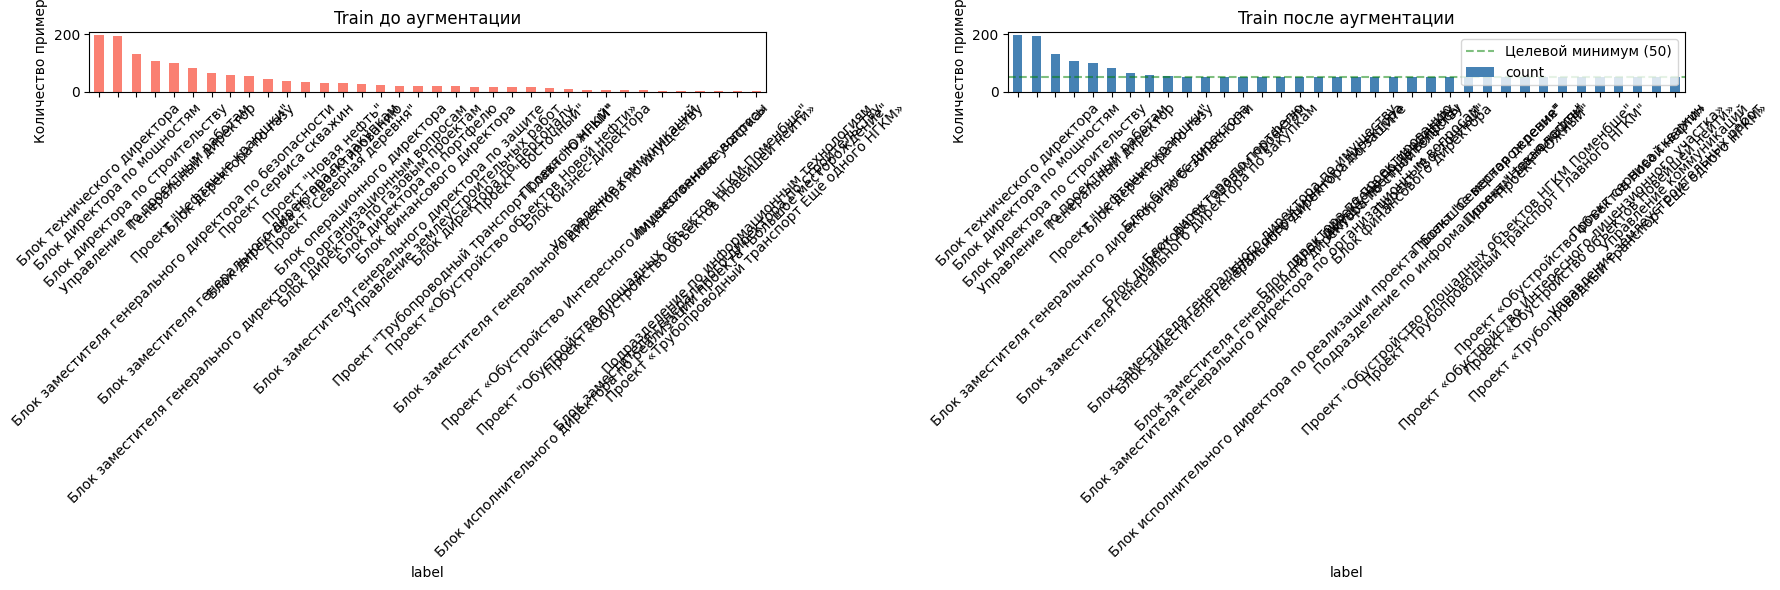

In [15]:
import matplotlib.pyplot as plt

# Сравниваем распределение: train до и после аугментации
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dist_train.plot(kind="bar", ax=axes[0], color="salmon")
axes[0].set_title("Train до аугментации")
axes[0].set_ylabel("Количество примеров")
axes[0].tick_params(axis="x", rotation=45)

dist_final.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Train после аугментации")
axes[1].set_ylabel("Количество примеров")
axes[1].axhline(y=50, color="g", linestyle="--", alpha=0.5, label="Целевой минимум (50)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

___
## Классификация — оценка качества аугментации

Обучаем на аугментированном train, оцениваем на отложенном test.
Данные загружаются один раз, все модели используют одни и те же эмбеддинги.

### Загрузка данных и эмбеддингов

In [16]:
from src.classification.evaluate import load_data, evaluate_model

X_train, y_train, X_test, y_test, label_names = load_data()

print(f"Train: {X_train.shape}, Test: {X_test.shape}, Классов: {len(label_names)}")

[Данные] Найден чекпоинт этапа 3: data_after_stage3.csv (2335 записей)
[Данные] Тестовая выборка: data_test.csv (341 записей)
[TF-IDF] Параметры: max_features=50000, ngram_range=(1, 2)
[TF-IDF] Обучаю на 2335 текстах...
[TF-IDF] Готово: train (2335, 45484), test (341, 45484)
[TF-IDF] Кэш сохранён (ключ: 78f9d15fb704)
Train: (2335, 45484), Test: (341, 45484), Классов: 36


### Linear SVM

In [17]:
from sklearn.svm import LinearSVC

augmented_results = []

augmented_results.append(evaluate_model(
    name="[Augmented] Linear SVM",
    estimator=LinearSVC(max_iter=10000, random_state=RANDOM_SEED, dual="auto"),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

КЛАССИФИКАЦИЯ: [Augmented] Linear SVM
[[Augmented] Linear SVM] Train: 2335, Test: 341, Классов: 36
[[Augmented] Linear SVM] Лучшие параметры: {'C': 10} (CV macro F1 = 0.8333)

[[Augmented] Linear SVM] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4820
  Macro F1:          0.4530

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.33      1.00      0.50         1
                                                      Блок деректора по газу       0.58      0.50      0.54        14
                                          Блок директора по газовым проектам       0.50      0.17      0.25         6
                                                 Блок директора по мощностям       0.78      0.94      0.85        48
                                                 Блок директора по персоналу       1.00      0.67      0.80         3
 

### Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

augmented_results.append(evaluate_model(
    name="[Augmented] Logistic Regression",
    estimator=LogisticRegression(solver="lbfgs", max_iter=1000, random_state=RANDOM_SEED),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"C": [0.01, 0.1, 1, 10]},
))

КЛАССИФИКАЦИЯ: [Augmented] Logistic Regression
[[Augmented] Logistic Regression] Train: 2335, Test: 341, Классов: 36
[[Augmented] Logistic Regression] Лучшие параметры: {'C': 10} (CV macro F1 = 0.7928)

[[Augmented] Logistic Regression] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4541
  Macro F1:          0.4616

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.50      1.00      0.67         1
                                                      Блок деректора по газу       0.80      0.29      0.42        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.71      0.94      0.81        48
                                                 Блок директора по персоналу       

### Multinomial Naive Bayes

In [19]:
from sklearn.naive_bayes import MultinomialNB

augmented_results.append(evaluate_model(
    name="[Augmented] Multinomial Naive Bayes",
    estimator=MultinomialNB(),
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    label_names=label_names,
    param_grid={"alpha": [0.01, 0.1, 0.5, 1.0]},
))

КЛАССИФИКАЦИЯ: [Augmented] Multinomial Naive Bayes
[[Augmented] Multinomial Naive Bayes] Train: 2335, Test: 341, Классов: 36
[[Augmented] Multinomial Naive Bayes] Лучшие параметры: {'alpha': 0.01} (CV macro F1 = 0.8142)

[[Augmented] Multinomial Naive Bayes] Результаты на тестовой выборке:
  Balanced Accuracy: 0.4652
  Macro F1:          0.4612

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.33      1.00      0.50         1
                                                      Блок деректора по газу       0.70      0.50      0.58        14
                                          Блок директора по газовым проектам       0.00      0.00      0.00         6
                                                 Блок директора по мощностям       0.69      0.98      0.81        48
                                                 Блок директо

### BERT-модели (fine-tuning)


In [20]:
from src.classification.rubert_classifier import train_and_evaluate

# df_final уже загружен выше (stage=3), df_test_baseline тоже
for cfg in RUBERT_CONFIGS:
    augmented_results.append(train_and_evaluate(
        df_train=df_final,
        df_test=df_test_baseline,
        model_name=cfg["model_name"],
        lr=cfg["lr"],
        num_epochs=cfg["num_epochs"],
        batch_size=cfg["batch_size"],
        name=f"[Augmented] {cfg['short_name']}",
    ))


[[Augmented] rubert-tiny2] Device: cuda, Model: cointegrated/rubert-tiny2


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[[Augmented] rubert-tiny2] Train: 2335, Test: 341, Классов: 36, Эпох: 15


  Epoch 1/15 — loss: 3.3563


  Epoch 2/15 — loss: 2.2430


...

  Epoch 11/15 — loss: 0.0340


  Epoch 12/15 — loss: 0.0218


  Epoch 13/15 — loss: 0.0164


  Epoch 14/15 — loss: 0.0139


  Epoch 15/15 — loss: 0.0131

[[Augmented] rubert-base] Результаты на тестовой выборке:
  Balanced Accuracy: 0.5221
  Macro F1:          0.4696

                                                                              precision    recall  f1-score   support

                                                       Блок бизнес-директора       0.33      1.00      0.50         1
                                                      Блок деректора по газу       0.60      0.43      0.50        14
                                          Блок директора по газовым проектам       0.33      0.17      0.22         6
                                                 Блок директора по мощностям       0.77      0.83      0.80        48
                                                 Блок директора по персоналу       0.50      1.00      0.67         3
                                                  Блок директора по портфелю       0.20      0.25      0.22         4
                            

___
## Сравнение: Baseline vs Augmented

Сводная таблица и график — как изменились метрики после аугментации для каждого классификатора.

Модель                    | Метрика              |   Baseline |  Augmented |      Delta
-----------------------------------------------------------------------------------
  Linear SVM              | Balanced Accuracy    |     0.4208 |     0.4820 | +   0.0612
  Linear SVM              | Macro F1             |     0.4434 |     0.4530 | +   0.0097
-----------------------------------------------------------------------------------
  Logistic Regression     | Balanced Accuracy    |     0.3089 |     0.4541 | +   0.1451
  Logistic Regression     | Macro F1             |     0.3350 |     0.4616 | +   0.1266
-----------------------------------------------------------------------------------
  Multinomial Naive Bayes | Balanced Accuracy    |     0.3849 |     0.4652 | +   0.0804
  Multinomial Naive Bayes | Macro F1             |     0.4026 |     0.4612 | +   0.0586
-----------------------------------------------------------------------------------
  rubert-tiny2            | Balanced Accuracy   

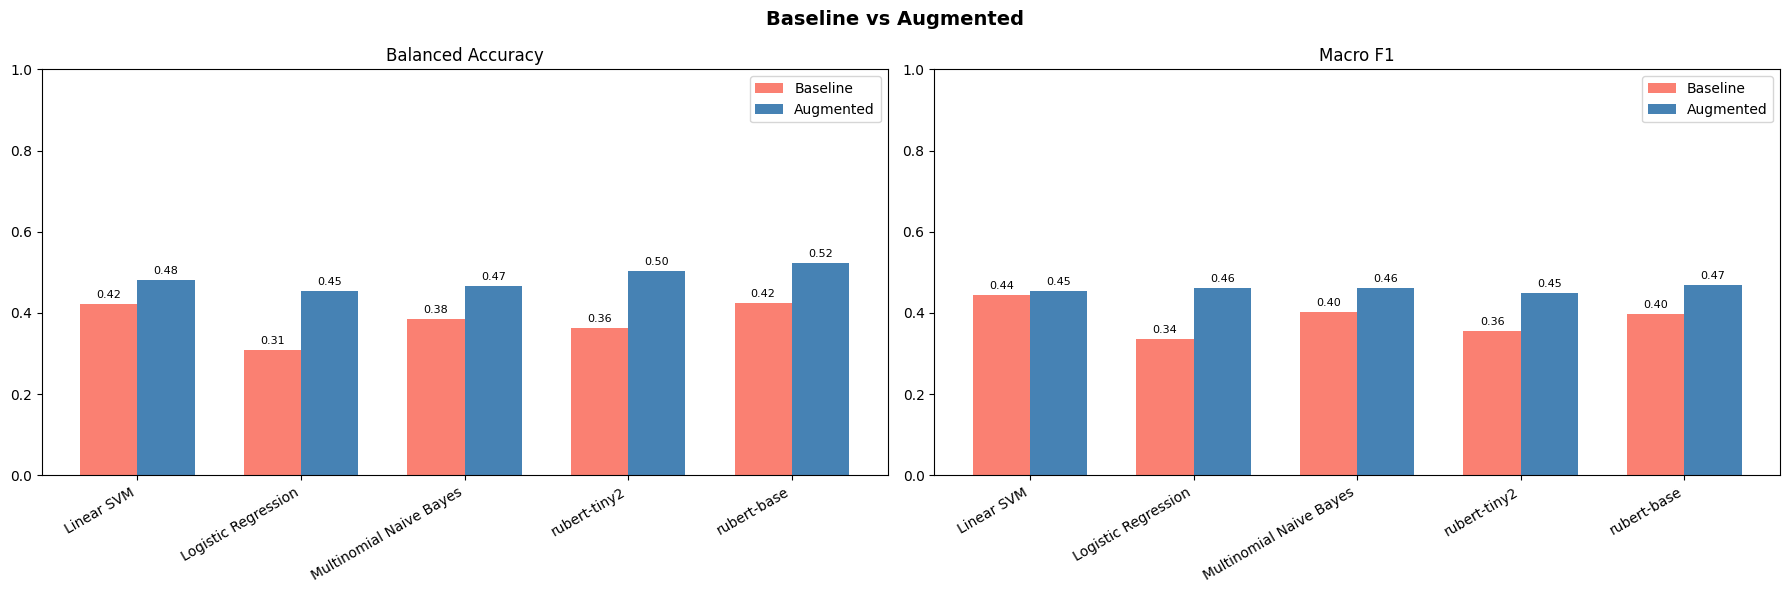

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Названия моделей (без префикса [Baseline]/[Augmented])
model_names = [r["name"].split("] ")[1] for r in baseline_results]

metrics = ["balanced_accuracy", "macro_f1"]
metric_labels = ["Balanced Accuracy", "Macro F1"]

# Таблица
rows = []
print(f"{'Модель':<25} | {'Метрика':<20} | {'Baseline':>10} | {'Augmented':>10} | {'Delta':>10}")
print("-" * 83)
for i, name in enumerate(model_names):
    for m, ml in zip(metrics, metric_labels):
        b = baseline_results[i][m]
        a = augmented_results[i][m]
        delta = a - b
        sign = "+" if delta >= 0 else ""
        print(f"  {name:<23} | {ml:<20} | {b:>10.4f} | {a:>10.4f} | {sign}{delta:>9.4f}")
    print("-" * 83)
    rows.append({
        "stage": "baseline",
        "model": name,
        "balanced_accuracy": round(float(baseline_results[i]["balanced_accuracy"]), 4),
        "macro_f1": round(float(baseline_results[i]["macro_f1"]), 4),
    })
    rows.append({
        "stage": "augmented",
        "model": name,
        "balanced_accuracy": round(float(augmented_results[i]["balanced_accuracy"]), 4),
        "macro_f1": round(float(augmented_results[i]["macro_f1"]), 4),
    })

# График
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(model_names))
width = 0.35

for ax, m, ml in zip(axes, metrics, metric_labels):
    vals_b = [r[m] for r in baseline_results]
    vals_a = [r[m] for r in augmented_results]

    bars_b = ax.bar(x - width/2, vals_b, width, label="Baseline", color="salmon")
    bars_a = ax.bar(x + width/2, vals_a, width, label="Augmented", color="steelblue")

    ax.set_title(ml)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.legend()

    # Подписи значений
    for bar in bars_b:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars_a:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Baseline vs Augmented", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


results_dir = Path("/content/drive/MyDrive/VKR/code/results")
results_dir.mkdir(exist_ok=True)
pd.DataFrame(rows).to_csv(results_dir / "classification_results.csv", index=False)
print(f"\nСохранено: {results_dir / 'classification_results.csv'}")


In [9]:
import pandas as pd
from pathlib import Path

# --- Сводим baseline и augmented результаты в один CSV ---
results_dir = Path(f"{PROJECT_ROOT}/results")
results_dir.mkdir(exist_ok=True)

rows = []
for r in baseline_results:
    rows.append({
        "stage": "baseline",
        "model": r["name"].replace("[Baseline] ", "").replace("[Augmented] ", ""),
        "balanced_accuracy": round(r["balanced_accuracy"], 4),
        "macro_f1": round(r["macro_f1"], 4),
    })
for r in augmented_results:
    rows.append({
        "stage": "augmented",
        "model": r["name"].replace("[Baseline] ", "").replace("[Augmented] ", ""),
        "balanced_accuracy": round(r["balanced_accuracy"], 4),
        "macro_f1": round(r["macro_f1"], 4),
    })

df_results = pd.DataFrame(rows)
csv_path = results_dir / "classification_results.csv"
df_results.to_csv(csv_path, index=False)
print(f"Сохранено: {csv_path}")
print()
print(df_results.to_string(index=False))


Сохранено: /Users/kvt/Documents/VKR/code/results/classification_results.csv

    stage                   model  balanced_accuracy  macro_f1
 baseline              Linear SVM             0.4820    0.4530
 baseline     Logistic Regression             0.4541    0.4616
 baseline Multinomial Naive Bayes             0.4652    0.4612
 baseline            rubert-tiny2             0.5027    0.4497
 baseline             rubert-base             0.5221    0.4696
augmented              Linear SVM             0.4820    0.4530
augmented     Logistic Regression             0.4541    0.4616
augmented Multinomial Naive Bayes             0.4652    0.4612
augmented            rubert-tiny2             0.5027    0.4497
augmented             rubert-base             0.5221    0.4696
